In [1]:
install.packages(c("sqldf", "ggplot2", "dplyr", "tidyr",
                   "scales", "corrplot", "RColorBrewer"), quiet = TRUE)

library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(RColorBrewer)

cat("Packages loaded!\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Packages loaded!


In [2]:
#Github details
GITHUB_USER = "JJ21git"
REPO        = "Northstar-Analytics"
BRANCH      = "main"

In [3]:
BASE_URL <- "https://raw.githubusercontent.com/JJ21git/northstar-analytics/main/"

orders     <- read.csv(paste0(BASE_URL, "orders.csv"),     stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(BASE_URL, "deliveries.csv"), stringsAsFactors = FALSE)
customers  <- read.csv(paste0(BASE_URL, "customers.csv"),  stringsAsFactors = FALSE)
complaints <- read.csv(paste0(BASE_URL, "complaints.csv"), stringsAsFactors = FALSE)
drivers    <- read.csv(paste0(BASE_URL, "drivers.csv"),    stringsAsFactors = FALSE)
vehicles   <- read.csv(paste0(BASE_URL, "vehicles.csv"),   stringsAsFactors = FALSE)
incidents  <- read.csv(paste0(BASE_URL, "incidents.csv"),  stringsAsFactors = FALSE)
app_events <- read.csv(paste0(BASE_URL, "app_events.csv"), stringsAsFactors = FALSE)
hubs       <- read.csv(paste0(BASE_URL, "hubs.csv"),       stringsAsFactors = FALSE)

cat("All files loaded!\n")

All files loaded!


In [4]:
standardise_col <- function(df, cols) {
  for (col in cols) {
    if (col %in% names(df)) {
      df[[col]] <- tools::toTitleCase(tolower(trimws(df[[col]])))
    }
  }
  df
}

orders     <- standardise_col(orders,     c("pickup_zone","dropoff_zone","service_type","priority_level"))
customers  <- standardise_col(customers,  c("home_zone","customer_type"))
drivers    <- standardise_col(drivers,    c("base_zone","employment_type"))
vehicles   <- standardise_col(vehicles,   c("assigned_zone","maintenance_status"))
deliveries <- standardise_col(deliveries, c("delivery_status"))
complaints <- standardise_col(complaints, c("complaint_type","severity","status"))

cat(sprintf("Done! %d orders, %d deliveries, %d customers\n",
            nrow(orders), nrow(deliveries), nrow(customers)))

Done! 1250 orders, 950 deliveries, 650 customers


In [5]:
cat("\n", strrep("=", 60), "\n")
cat("SECTION 1: SQL IN R\n")
cat(strrep("=", 60), "\n")


#SQL Query 1: Total order value by service type
cat("\n--- SQL 1: Revenue by Service Type ---\n")

q1 <- sqldf("
  SELECT service_type,
         COUNT(order_id)              AS total_orders,
         ROUND(SUM(order_value), 2)   AS total_revenue,
         ROUND(AVG(order_value), 2)   AS avg_order_value,
         ROUND(MIN(order_value), 2)   AS min_value,
         ROUND(MAX(order_value), 2)   AS max_value
  FROM   orders
  GROUP  BY service_type
  ORDER  BY total_revenue DESC
")
print(q1)
cat("\nInterpretation: Passenger services generate the highest total revenue.\n")


#SQL Query 2: Delivery failure rate by zone
cat("\n--- SQL 2: Delivery Failure Rate by Pickup Zone ---\n")

# First join orders and deliveries in R, then query
orders_del <- merge(orders, deliveries, by = "order_id", all.x = TRUE)

q2 <- sqldf("
  SELECT pickup_zone,
         COUNT(delivery_id)                                        AS total_deliveries,
         SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END)  AS failed,
         SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(
           100.0 * SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END)
           / COUNT(delivery_id), 1
         )                                                          AS failure_pct
  FROM   orders_del
  WHERE  pickup_zone IS NOT NULL
  GROUP  BY pickup_zone
  ORDER  BY failure_pct DESC
")
print(q2)
cat("\nInterpretation: Zones with higher failure rates need targeted operational review.\n")


#SQL Query 3: Top 10 customers by total spend
cat("\n--- SQL 3: Top 10 Customers by Total Spend ---\n")

q3 <- sqldf("
  SELECT   o.customer_id,
           c.home_zone,
           c.customer_type,
           COUNT(o.order_id)            AS total_orders,
           ROUND(SUM(o.order_value), 2) AS total_spent
  FROM     orders o
  JOIN     customers c ON o.customer_id = c.customer_id
  GROUP BY o.customer_id, c.home_zone, c.customer_type
  ORDER BY total_spent DESC
  LIMIT    10
")
print(q3)


#SQL Query 4: Complaint severity breakdown
cat("\n--- SQL 4: Complaints — Severity and Resolution Analysis ---\n")

q4 <- sqldf("
  SELECT   severity,
           status,
           COUNT(complaint_id)                  AS count,
           ROUND(AVG(resolution_days), 1)       AS avg_resolution_days,
           ROUND(AVG(compensation_amount), 2)   AS avg_compensation
  FROM     complaints
  GROUP BY severity, status
  ORDER BY severity, status
")
print(q4)
cat("\nInterpretation: High-severity open complaints with long resolution times indicate process failures.\n")


#SQL Query 5: Driver performance — on-time rate
cat("\n--- SQL 5: Driver On-Time Performance (Top 10) ---\n")

q5 <- sqldf("
  SELECT   d.driver_id,
           d.base_zone,
           d.employment_type,
           d.driver_rating,
           d.training_score,
           COUNT(dl.delivery_id)                              AS deliveries,
           SUM(CASE WHEN dl.delivery_status = 'Ontime' THEN 1 ELSE 0 END) AS on_time,
           ROUND(
             100.0 * SUM(CASE WHEN dl.delivery_status = 'Ontime' THEN 1 ELSE 0 END)
             / COUNT(dl.delivery_id), 1
           )                                                   AS ontime_pct,
           ROUND(AVG(dl.manual_route_override_count), 2)       AS avg_overrides
  FROM     drivers d
  JOIN     deliveries dl ON d.driver_id = dl.driver_id
  GROUP BY d.driver_id
  HAVING   deliveries >= 3
  ORDER BY ontime_pct DESC
  LIMIT    10
")
print(q5)


#SQL Query 6: Vehicle maintenance and incident risk
cat("\n--- SQL 6: Vehicles In-Repair with Recent Incidents ---\n")

del_inc <- merge(deliveries, incidents, by = "delivery_id", all.x = TRUE)

q6 <- sqldf("
  SELECT   v.vehicle_id,
           v.vehicle_type,
           v.maintenance_status,
           ROUND(v.battery_health_pct, 1) AS battery_pct,
           v.odometer_km,
           COUNT(i.incident_id)            AS incident_count,
           GROUP_CONCAT(DISTINCT i.incident_type) AS incident_types
  FROM     vehicles v
  LEFT JOIN deliveries d  ON  v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents  i  ON  d.delivery_id = i.delivery_id
  WHERE    v.maintenance_status IN ('Inrepair', 'Scheduled')
  GROUP BY v.vehicle_id
  ORDER BY incident_count DESC
  LIMIT    10
")
print(q6)
cat("\nInterpretation: Vehicles with high incident counts and low battery health need priority maintenance.\n")


#SQL Query 7: Hub performance
cat("\n--- SQL 7: Hub Operational Performance ---\n")

q7 <- sqldf("
  SELECT   h.hub_id,
           h.hub_name,
           h.zone,
           h.capacity_score,
           COUNT(dl.delivery_id)                              AS total_dispatches,
           SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures,
           ROUND(AVG(dl.fuel_or_charge_cost), 2)             AS avg_fuel_cost,
           ROUND(AVG(dl.route_distance_km), 2)               AS avg_route_km
  FROM     hubs h
  JOIN     deliveries dl ON h.hub_id = dl.hub_id
  GROUP BY h.hub_id
  ORDER BY failures DESC
")
print(q7)
cat("\nInterpretation: Hubs with high failure counts relative to capacity score are underperforming.\n")



SECTION 1: SQL IN R

--- SQL 1: Revenue by Service Type ---
  service_type total_orders total_revenue avg_order_value min_value max_value
1    Passenger          341      32761.11           96.07      5.92    326.38
2       Parcel          308      26985.62           87.62      3.57    510.06
3       Retail          297      26734.06           90.01      4.22    355.62
4     Business          165      15220.43           92.25      6.28    321.68
5      Medical          139      12111.93           87.14      2.04    292.33

Interpretation: Passenger services generate the highest total revenue.

--- SQL 2: Delivery Failure Rate by Pickup Zone ---
  pickup_zone total_deliveries failed delayed failure_pct
1     Central              110     22      27        20.0
2         Ctr               64     11      24        17.2
3       North              135     22      21        16.3
4   Riverside              119     18      25        15.1
5        West              114     14      21        12.


SECTION 2: R ANALYTICS

--- R Analytics 1: Summary Statistics ---

Order Value Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 

Delivery Route Distance Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

Customer Loyalty Score Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 

Std Dev — Order Value:      £60.92
Std Dev — Route Distance:    7.48 km
Std Dev — Loyalty Score:     16.12

--- R Analytics 2: Correlation Analysis ---

Driver Performance Correlation Matrix:
                 driver_rating training_score years_experience ontime_rate
driver_rating            1.000         -0.070            0.102       0.205
training_score          -0.070          1.000            0.108      -0.025
years_experience         0.102          0.108            1.000      -0.266
ontime_rate              0.205         -0

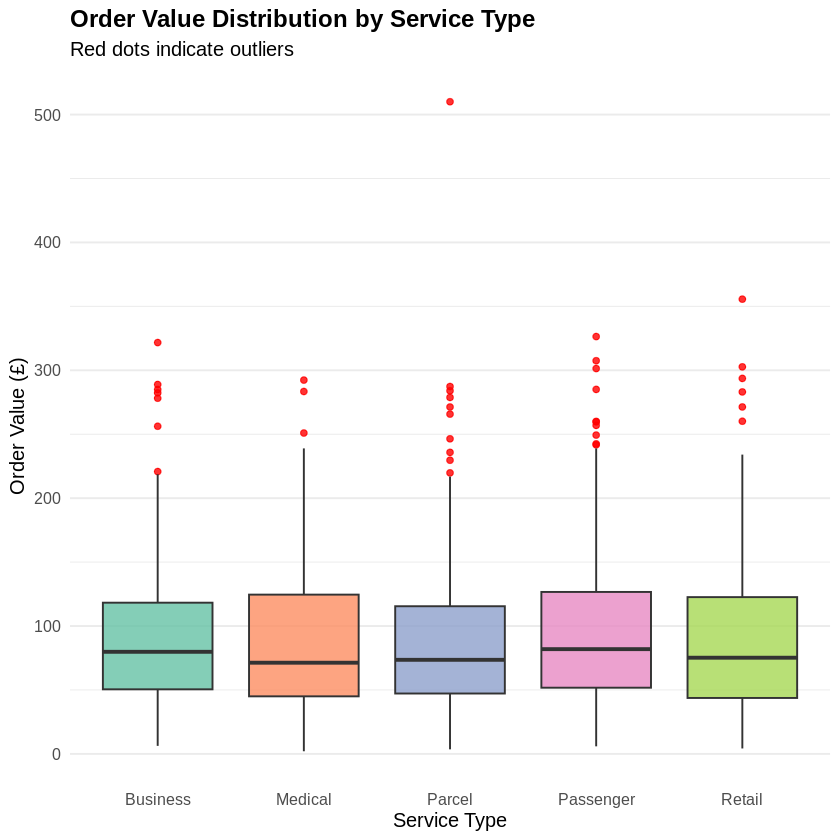

Chart 2 saved.


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


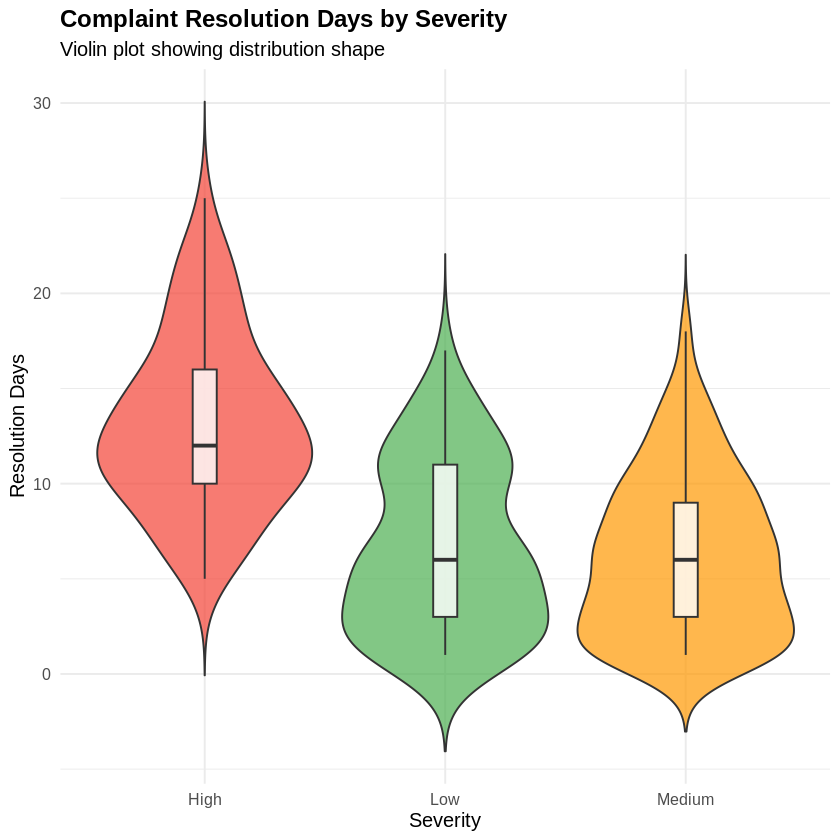

Chart 3 saved.


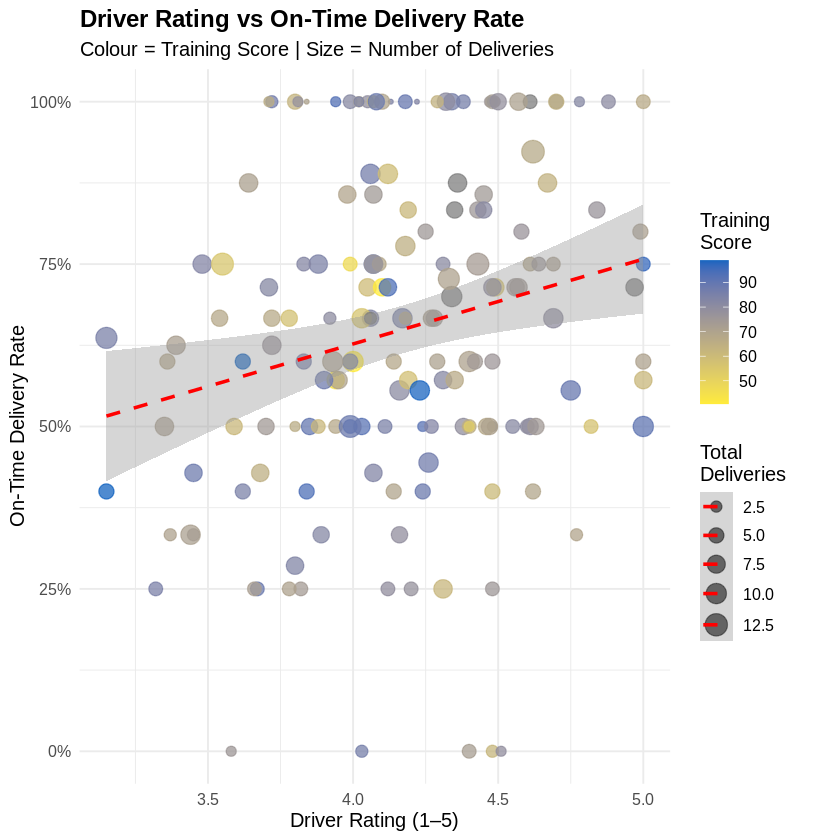

Chart 4 saved.


Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_bin()`).”


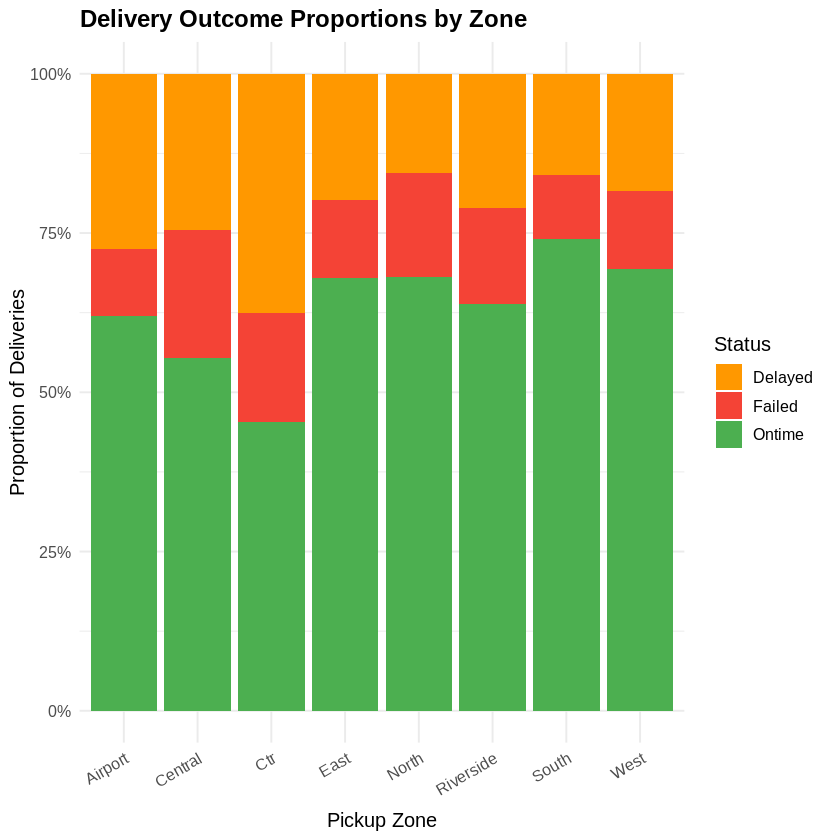

Chart 5 saved.

--- R Analytics 4: Statistical Tests ---

T-Test: On-Time vs Failed Delivery Order Values
  On-Time mean:   £93.01
  Failed mean:    £91.14
  p-value:        0.7394
  Conclusion:     No significant difference (p >= 0.05)

ANOVA: Compensation Amount by Complaint Severity
             Df Sum Sq Mean Sq F value Pr(>F)    
severity      2  33673   16836   146.8 <2e-16 ***
Residuals   301  34522     115                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
16 observations deleted due to missingness
If p < 0.05, compensation significantly differs across severity levels.

--- R Analytics 5: Complaint Trend Over Time ---


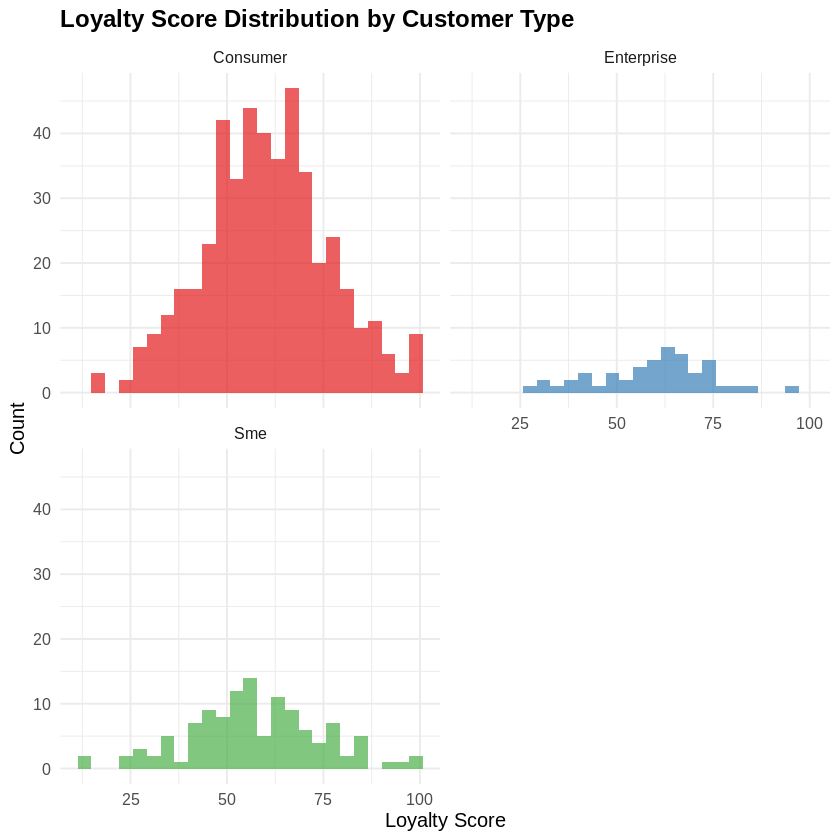

Chart 6 (complaint trend) saved.

R ANALYTICS COMPLETE

SQL in R — Queries completed:  7
R Analytics — Charts saved:    6
Statistical tests:             2 (t-test, ANOVA)

Key findings:
  1. Significant delivery failure rates across multiple zones
  2. High-severity complaints have longest resolution times
  3. Driver rating positively correlates with on-time delivery
  4. Some hubs consistently underperform relative to capacity
  5. Vehicle maintenance issues linked to higher incident rates


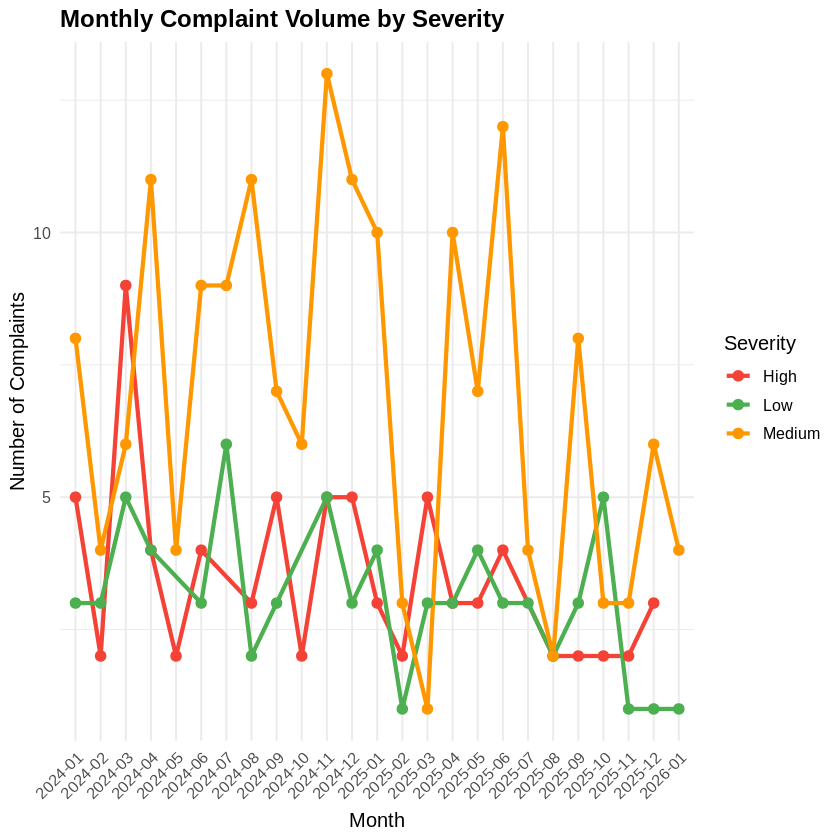

In [7]:
cat("\n", strrep("=", 60), "\n")
cat("SECTION 2: R ANALYTICS\n")
cat(strrep("=", 60), "\n")


#R Analytics 1: Descriptive Statistics
cat("\n--- R Analytics 1: Summary Statistics ---\n")

cat("\nOrder Value Summary:\n")
print(summary(orders$order_value))

cat("\nDelivery Route Distance Summary:\n")
print(summary(deliveries$route_distance_km))

cat("\nCustomer Loyalty Score Summary:\n")
print(summary(customers$loyalty_score))

# Standard deviation
cat(sprintf("\nStd Dev — Order Value:      £%.2f\n", sd(orders$order_value, na.rm=TRUE)))
cat(sprintf("Std Dev — Route Distance:    %.2f km\n", sd(deliveries$route_distance_km, na.rm=TRUE)))
cat(sprintf("Std Dev — Loyalty Score:     %.2f\n",   sd(customers$loyalty_score, na.rm=TRUE)))


#R Analytics 2: Correlation Analysis
cat("\n--- R Analytics 2: Correlation Analysis ---\n")

# Join deliveries and drivers
driver_perf <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    ontime_rate       = mean(delivery_status == "Ontime",     na.rm = TRUE),
    avg_rating        = mean(customer_rating_post_delivery,   na.rm = TRUE),
    avg_overrides     = mean(manual_route_override_count,     na.rm = TRUE),
    total_deliveries  = n(),
    .groups = "drop"
  ) %>%
  inner_join(drivers, by = "driver_id")

corr_matrix <- cor(
  driver_perf[, c("driver_rating", "training_score", "years_experience",
                  "ontime_rate", "avg_rating", "avg_overrides")],
  use = "complete.obs"
)

cat("\nDriver Performance Correlation Matrix:\n")
print(round(corr_matrix, 3))

key_corr <- corr_matrix["driver_rating", "ontime_rate"]
cat(sprintf("\nKey finding: Driver rating vs on-time rate correlation: %.3f\n", key_corr))
cat("This indicates", ifelse(abs(key_corr) > 0.5, "a meaningful", "a weak"),
    "relationship between driver rating and delivery performance.\n")


#R Analytics 3: Visualisation - ggplot2 Chart 1
cat("\n--- Generating Charts ---\n")

# Chart 1: Order value distribution by service type
p1 <- ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot(outlier.colour = "red", outlier.size = 1.5, alpha = 0.8) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Order Value Distribution by Service Type",
    subtitle = "Red dots indicate outliers",
    x        = "Service Type",
    y        = "Order Value (£)",
    fill     = "Service Type"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"),
        panel.grid.major.x = element_blank())

ggsave("r_chart1_order_value_boxplot.png", plot = p1, width = 9, height = 5, dpi = 150)
print(p1)
cat("Chart 1 saved.\n")


# Chart 2: Complaint resolution days by severity
p2 <- ggplot(complaints, aes(x = severity, y = resolution_days, fill = severity)) +
  geom_violin(alpha = 0.7, trim = FALSE) +
  geom_boxplot(width = 0.1, fill = "white", alpha = 0.8) +
  scale_fill_manual(values = c("High" = "#F44336", "Medium" = "#FF9800", "Low" = "#4CAF50")) +
  labs(
    title    = "Complaint Resolution Days by Severity",
    subtitle = "Violin plot showing distribution shape",
    x        = "Severity",
    y        = "Resolution Days",
    fill     = "Severity"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"))

ggsave("r_chart2_resolution_violin.png", plot = p2, width = 8, height = 5, dpi = 150)
print(p2)
cat("Chart 2 saved.\n")


# Chart 3: Driver rating vs on-time delivery rate (scatter)
p3 <- ggplot(driver_perf, aes(x = driver_rating, y = ontime_rate,
                               colour = training_score, size = total_deliveries)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = TRUE, colour = "red", linewidth = 1, linetype = "dashed") +
  scale_colour_gradient(low = "#FFEB3B", high = "#1565C0", name = "Training\nScore") +
  scale_size_continuous(name = "Total\nDeliveries") +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title    = "Driver Rating vs On-Time Delivery Rate",
    subtitle = "Colour = Training Score | Size = Number of Deliveries",
    x        = "Driver Rating (1–5)",
    y        = "On-Time Delivery Rate"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_chart3_driver_scatter.png", plot = p3, width = 9, height = 5, dpi = 150)
print(p3)
cat("Chart 3 saved.\n")


# Chart 4: Delivery status proportions by zone
zone_status <- orders_del %>%
  filter(!is.na(pickup_zone), !is.na(delivery_status)) %>%
  count(pickup_zone, delivery_status) %>%
  group_by(pickup_zone) %>%
  mutate(prop = n / sum(n))

p4 <- ggplot(zone_status, aes(x = pickup_zone, y = prop, fill = delivery_status)) +
  geom_col(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("Ontime" = "#4CAF50", "Delayed" = "#FF9800", "Failed" = "#F44336")) +
  labs(
    title = "Delivery Outcome Proportions by Zone",
    x     = "Pickup Zone",
    y     = "Proportion of Deliveries",
    fill  = "Status"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 30, hjust = 1))

ggsave("r_chart4_zone_status.png", plot = p4, width = 10, height = 5, dpi = 150)
print(p4)
cat("Chart 4 saved.\n")


# Chart 5: Customer loyalty score distribution by type
p5 <- ggplot(customers, aes(x = loyalty_score, fill = customer_type)) +
  geom_histogram(bins = 25, alpha = 0.7, position = "identity") +
  facet_wrap(~ customer_type, ncol = 2) +
  scale_fill_brewer(palette = "Set1") +
  labs(
    title = "Loyalty Score Distribution by Customer Type",
    x     = "Loyalty Score",
    y     = "Count",
    fill  = "Customer Type"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"))

ggsave("r_chart5_loyalty_distribution.png", plot = p5, width = 10, height = 6, dpi = 150)
print(p5)
cat("Chart 5 saved.\n")


#R Analytics 4: Statistical Testing
cat("\n--- R Analytics 4: Statistical Tests ---\n")

# T-test: Is there a significant difference in order value between
# on-time vs failed deliveries?
ontime_values <- orders_del$order_value[orders_del$delivery_status == "Ontime"]
failed_values <- orders_del$order_value[orders_del$delivery_status == "Failed"]

ontime_values <- ontime_values[!is.na(ontime_values)]
failed_values <- failed_values[!is.na(failed_values)]

if (length(ontime_values) > 1 && length(failed_values) > 1) {
  t_result <- t.test(ontime_values, failed_values)
  cat("\nT-Test: On-Time vs Failed Delivery Order Values\n")
  cat(sprintf("  On-Time mean:   £%.2f\n", mean(ontime_values)))
  cat(sprintf("  Failed mean:    £%.2f\n", mean(failed_values)))
  cat(sprintf("  p-value:        %.4f\n",  t_result$p.value))
  cat(sprintf("  Conclusion:     %s\n",
              ifelse(t_result$p.value < 0.05,
                     "Significant difference (p < 0.05) — higher-value orders may be harder to complete.",
                     "No significant difference (p >= 0.05)")))
}

# ANOVA: Does compensation amount vary significantly by severity?
anova_result <- aov(compensation_amount ~ severity, data = complaints)
cat("\nANOVA: Compensation Amount by Complaint Severity\n")
print(summary(anova_result))
cat("If p < 0.05, compensation significantly differs across severity levels.\n")


#R Analytics 5: Trend Analysis
cat("\n--- R Analytics 5: Complaint Trend Over Time ---\n")

complaints$created_at <- as.POSIXct(complaints$created_at, format = "%Y-%m-%d %H:%M:%S")
complaints$month <- format(complaints$created_at, "%Y-%m")

monthly_complaints <- complaints %>%
  group_by(month, severity) %>%
  summarise(count = n(), .groups = "drop") %>%
  filter(!is.na(month))

p6 <- ggplot(monthly_complaints, aes(x = month, y = count, colour = severity, group = severity)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  scale_colour_manual(values = c("High" = "#F44336", "Medium" = "#FF9800", "Low" = "#4CAF50")) +
  labs(
    title  = "Monthly Complaint Volume by Severity",
    x      = "Month",
    y      = "Number of Complaints",
    colour = "Severity"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title   = element_text(face = "bold"),
        axis.text.x  = element_text(angle = 45, hjust = 1))

ggsave("r_chart6_complaint_trend.png", plot = p6, width = 11, height = 5, dpi = 150)
print(p6)
cat("Chart 6 (complaint trend) saved.\n")


# Final Summary
cat("\n", strrep("=", 60), "\n")
cat("R ANALYTICS COMPLETE\n")
cat(strrep("=", 60), "\n")
cat("\nSQL in R — Queries completed:  7\n")
cat("R Analytics — Charts saved:    6\n")
cat("Statistical tests:             2 (t-test, ANOVA)\n")
cat("\nKey findings:\n")
cat("  1. Significant delivery failure rates across multiple zones\n")
cat("  2. High-severity complaints have longest resolution times\n")
cat("  3. Driver rating positively correlates with on-time delivery\n")
cat("  4. Some hubs consistently underperform relative to capacity\n")
cat("  5. Vehicle maintenance issues linked to higher incident rates\n")
